<a href="https://colab.research.google.com/github/rithikaraoponugoti4-wq/block-chain-clone/blob/main/Task_1_Analyse_Covid19_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd #import libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("covid_19_clean_complete.csv") #load dataset

print(df.head())
print(df.columns)

  Province/State Country/Region       Lat       Long        Date  Confirmed  \
0            NaN    Afghanistan  33.93911  67.709953  2020-01-22          0   
1            NaN        Albania  41.15330  20.168300  2020-01-22          0   
2            NaN        Algeria  28.03390   1.659600  2020-01-22          0   
3            NaN        Andorra  42.50630   1.521800  2020-01-22          0   
4            NaN         Angola -11.20270  17.873900  2020-01-22          0   

   Deaths  Recovered  Active             WHO Region  
0       0          0       0  Eastern Mediterranean  
1       0          0       0                 Europe  
2       0          0       0                 Africa  
3       0          0       0                 Europe  
4       0          0       0                 Africa  
Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')


In [ ]:
print(df.info()) #understanding the data
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB
None
Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64


In [ ]:
df['Date'] = pd.to_datetime(df['Date']) # Convert date      #DATA CLEANING
df = df.dropna() #drop the missing values
df = df.sort_values(by='Date') #sort the values

In [ ]:
china = df[df['Country/Region'] == 'China']  #Filter the data (data=china)
china = china.reset_index(drop=True)

In [ ]:
china['Daily Cases'] = china['Confirmed'].diff() #Feature Extraction
china['Daily Deaths'] = china['Deaths'].diff()
china['Daily Recovered'] = china['Recovered'].diff()

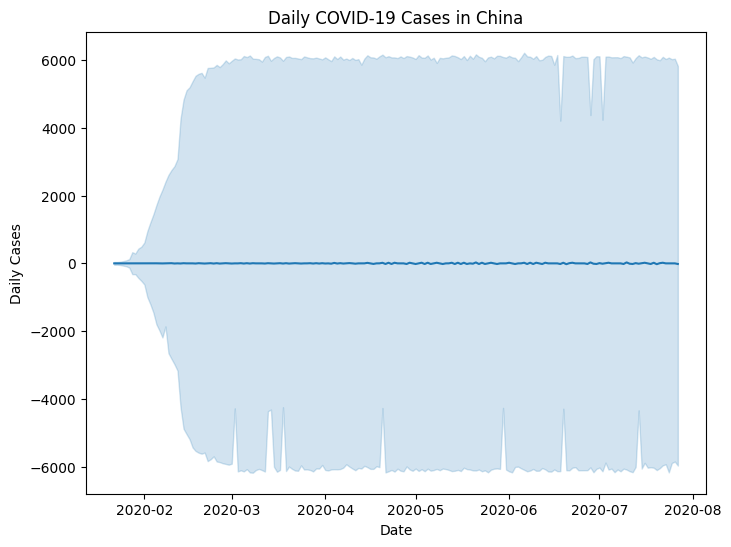

In [ ]:
plt.figure(figsize=(8,6)) #daily cases #data visualization
sns.lineplot(x='Date', y='Daily Cases', data=china)
plt.title("Daily COVID-19 Cases in China")
plt.show()

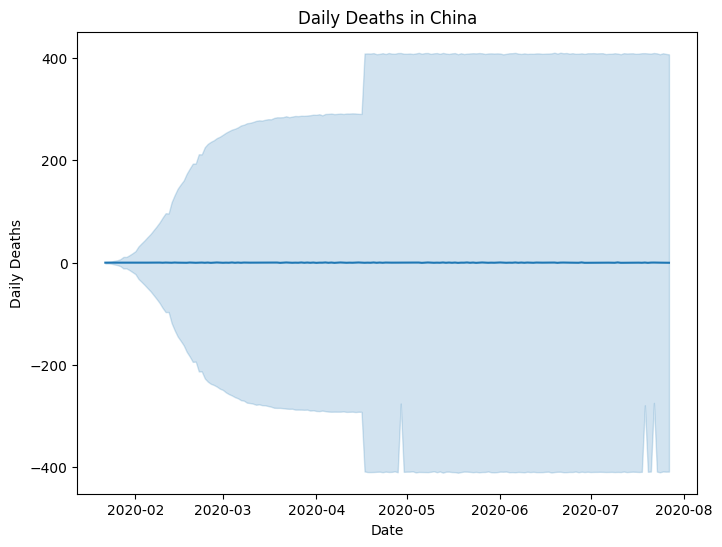

In [ ]:
plt.figure(figsize=(8,6))
sns.lineplot(x='Date', y='Daily Deaths', data=china)
plt.title("Daily Deaths in China")
plt.show()

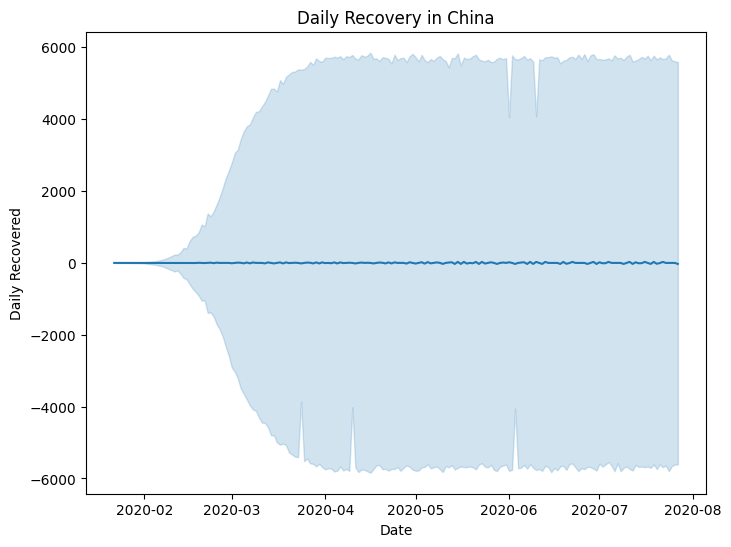

In [ ]:
plt.figure(figsize=(8,6))
sns.lineplot(x='Date', y='Daily Recovered', data=china)
plt.title("Daily Recovery in China")
plt.show()

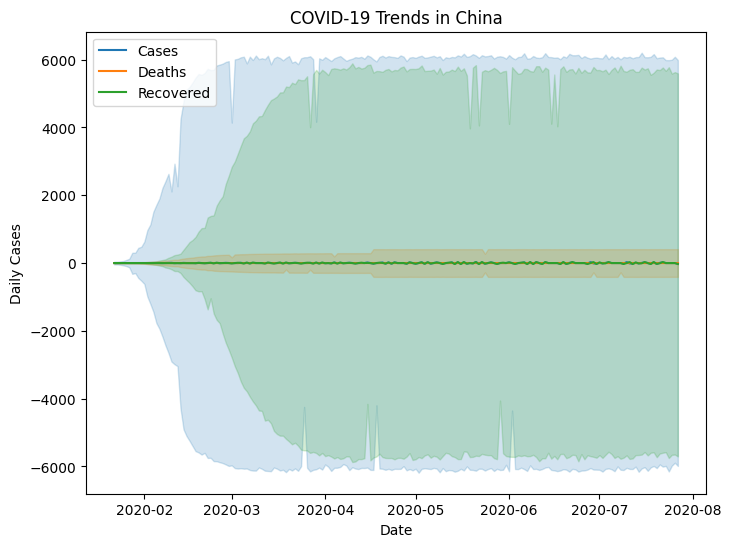

In [ ]:
plt.figure(figsize=(8,6))

sns.lineplot(x='Date', y='Daily Cases', data=china, label='Cases')
sns.lineplot(x='Date', y='Daily Deaths', data=china, label='Deaths')
sns.lineplot(x='Date', y='Daily Recovered', data=china, label='Recovered')

plt.title("COVID-19 Trends in China")
plt.legend()
plt.show()

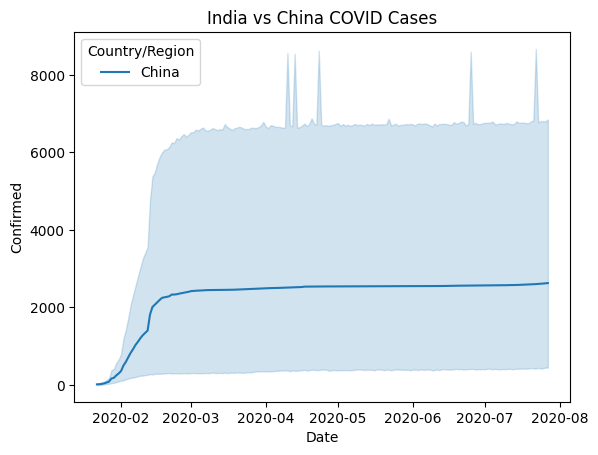

In [ ]:
compare = df[df['Country/Region'].isin(['India','China'])]

sns.lineplot(x='Date', y='Confirmed', hue='Country/Region', data=compare)
plt.title("India vs China COVID Cases")
plt.show()